In [1]:
import os
import time
import datetime
import pandas as pd
import numpy as np
import sys
from ctgan import CTGAN

# ignore all warnings
import warnings
warnings.filterwarnings('ignore')
import torch

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"GPU device: {torch.cuda.get_device_name(0)}")
    print(f"Number of GPUs: {torch.cuda.device_count()}")
else:
    print("Running on CPU")

PyTorch version: 2.1.0
CUDA available: False
Running on CPU


In [2]:
dataset_file  =  "/Users/vsekar/AINTEC_Tutorial/generative-trace-tutorials/data/small-scale/caida/raw.csv"

In [3]:
df = pd.read_csv(dataset_file)
df = df.head(1000) 

In [4]:
print(f"\nDataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nFirst few rows:")
df.head()


Dataset shape: (1000, 15)
Columns: ['srcip', 'dstip', 'srcport', 'dstport', 'proto', 'time', 'pkt_len', 'version', 'ihl', 'tos', 'id', 'flag', 'off', 'ttl', 'chksum']

First few rows:


,srcip,dstip,srcport,dstport,proto,time,pkt_len,version,ihl,tos,id,flag,off,ttl,chksum
0,2482664220,846812372,443,34294,TCP,1521118773289502,40,4,5,40,0,2,0,52,47172
1,2361935266,1074109248,80,42867,TCP,1521118773289519,1500,4,5,0,15922,2,0,60,19770
2,3656538983,3617679681,9926,49217,TCP,1521118773289529,1400,4,5,24,3559,2,0,55,47684
3,3307968672,3978971486,32276,80,TCP,1521118773289530,52,4,5,0,47404,2,0,59,62018
4,2361935266,1074109248,80,42867,TCP,1521118773289535,1500,4,5,0,15923,2,0,60,19769


In [5]:
start_time = time.time()
discrete_columns = ["srcip","dstip","srcport","dstport","proto","version","ihl","tos","flag","off"]
numerical_columns = ["time","pkt_len","id","ttl"]

model_name = "CTGAN"
dataset_name = "caida"


ctgan = CTGAN(epochs=20, verbose=True)
print("starting training")

starting training


In [6]:
ctgan.fit(df, discrete_columns)


Epoch 1, Loss G:  2.7620,Loss D: -0.0180
Epoch 2, Loss G:  2.8152,Loss D: -0.0621
Epoch 3, Loss G:  2.6862,Loss D: -0.1177
Epoch 4, Loss G:  2.8509,Loss D: -0.2206
Epoch 5, Loss G:  2.7640,Loss D: -0.2701
Epoch 6, Loss G:  2.9673,Loss D: -0.3091
Epoch 7, Loss G:  2.8871,Loss D: -0.3455
Epoch 8, Loss G:  2.8308,Loss D: -0.3351
Epoch 9, Loss G:  2.9640,Loss D: -0.4167
Epoch 10, Loss G:  2.8641,Loss D: -0.4231
Epoch 11, Loss G:  2.8125,Loss D: -0.4286
Epoch 12, Loss G:  2.7692,Loss D: -0.4370
Epoch 13, Loss G:  2.8714,Loss D: -0.4728
Epoch 14, Loss G:  2.9040,Loss D: -0.4892
Epoch 15, Loss G:  2.8453,Loss D: -0.5304
Epoch 16, Loss G:  2.8298,Loss D: -0.4999
Epoch 17, Loss G:  2.9987,Loss D: -0.5898
Epoch 18, Loss G:  2.7736,Loss D: -0.6501
Epoch 19, Loss G:  2.8125,Loss D: -0.5739
Epoch 20, Loss G:  2.8371,Loss D: -0.5424


In [7]:
synthetic_data = ctgan.sample(1000)


In [8]:
print(synthetic_data)

          srcip       dstip  srcport  dstport proto              time  \
0     360214354  3441494012    58743    49526   TCP  1521118773290744   
1    3585093842  1074109393    21434    58902   TCP  1521118773291606   
2     843783394  3391004245     8101    63225   UDP  1521118773290517   
3    3585093887  3350327453     4050       23   TCP  1521118773290490   
4    2651139352   843176031    10784    54050   TCP  1521118773291146   
..          ...         ...      ...      ...   ...               ...   
995  3978974068  3349791226    12963    40304   TCP  1521118773289891   
996  3554972867   843176031    50418    29802   TCP  1521118773291933   
997  1903162819  3350331145    10886    35163   TCP  1521118773291464   
998  1264312160  3337861944    14595    34466   UDP  1521118773290903   
999   357843349  1962334000     4877    56446   TCP  1521118773290981   

     pkt_len  version  ihl  tos     id  flag  off  ttl  chksum  
0        226        4    5    8  15189     2    0   70   6

In [9]:
from metric import eval_metrics

real_df = df.copy()
gen_df = synthetic_data

print(f"\nReal data shape: {real_df.shape}")
print(f"Generated data shape: {gen_df.shape}")
print(f"Real data columns: {list(real_df.columns)}")
print(f"Generated data columns: {list(gen_df.columns)}")
print("\nRunning comprehensive fidelity evaluation...")
print("This may take a few minutes depending on data size...\n")

# Run evaluation with multiple metrics
# n=10 means we look at top-10 values for various distributions
# n_threads controls parallel processing (adjust based on your CPU)
rst = eval_metrics(real_df, gen_df, n=10, n_threads=16)




Real data shape: (1000, 15)
Generated data shape: (1000, 15)
Real data columns: ['srcip', 'dstip', 'srcport', 'dstport', 'proto', 'time', 'pkt_len', 'version', 'ihl', 'tos', 'id', 'flag', 'off', 'ttl', 'chksum']
Generated data columns: ['srcip', 'dstip', 'srcport', 'dstport', 'proto', 'time', 'pkt_len', 'version', 'ihl', 'tos', 'id', 'flag', 'off', 'ttl', 'chksum']

Running comprehensive fidelity evaluation...
This may take a few minutes depending on data size...



Evaluating Flow Stateful Metrics: 100%|█████| 42/42 [00:00<00:00, 64.31metric/s]



Average Scores by Category:
  Packet-Level:            0.2226
  Flow-Level Stateless:    0.6226
  Flow-Level Stateful:     0.6932

Generating visualizations...



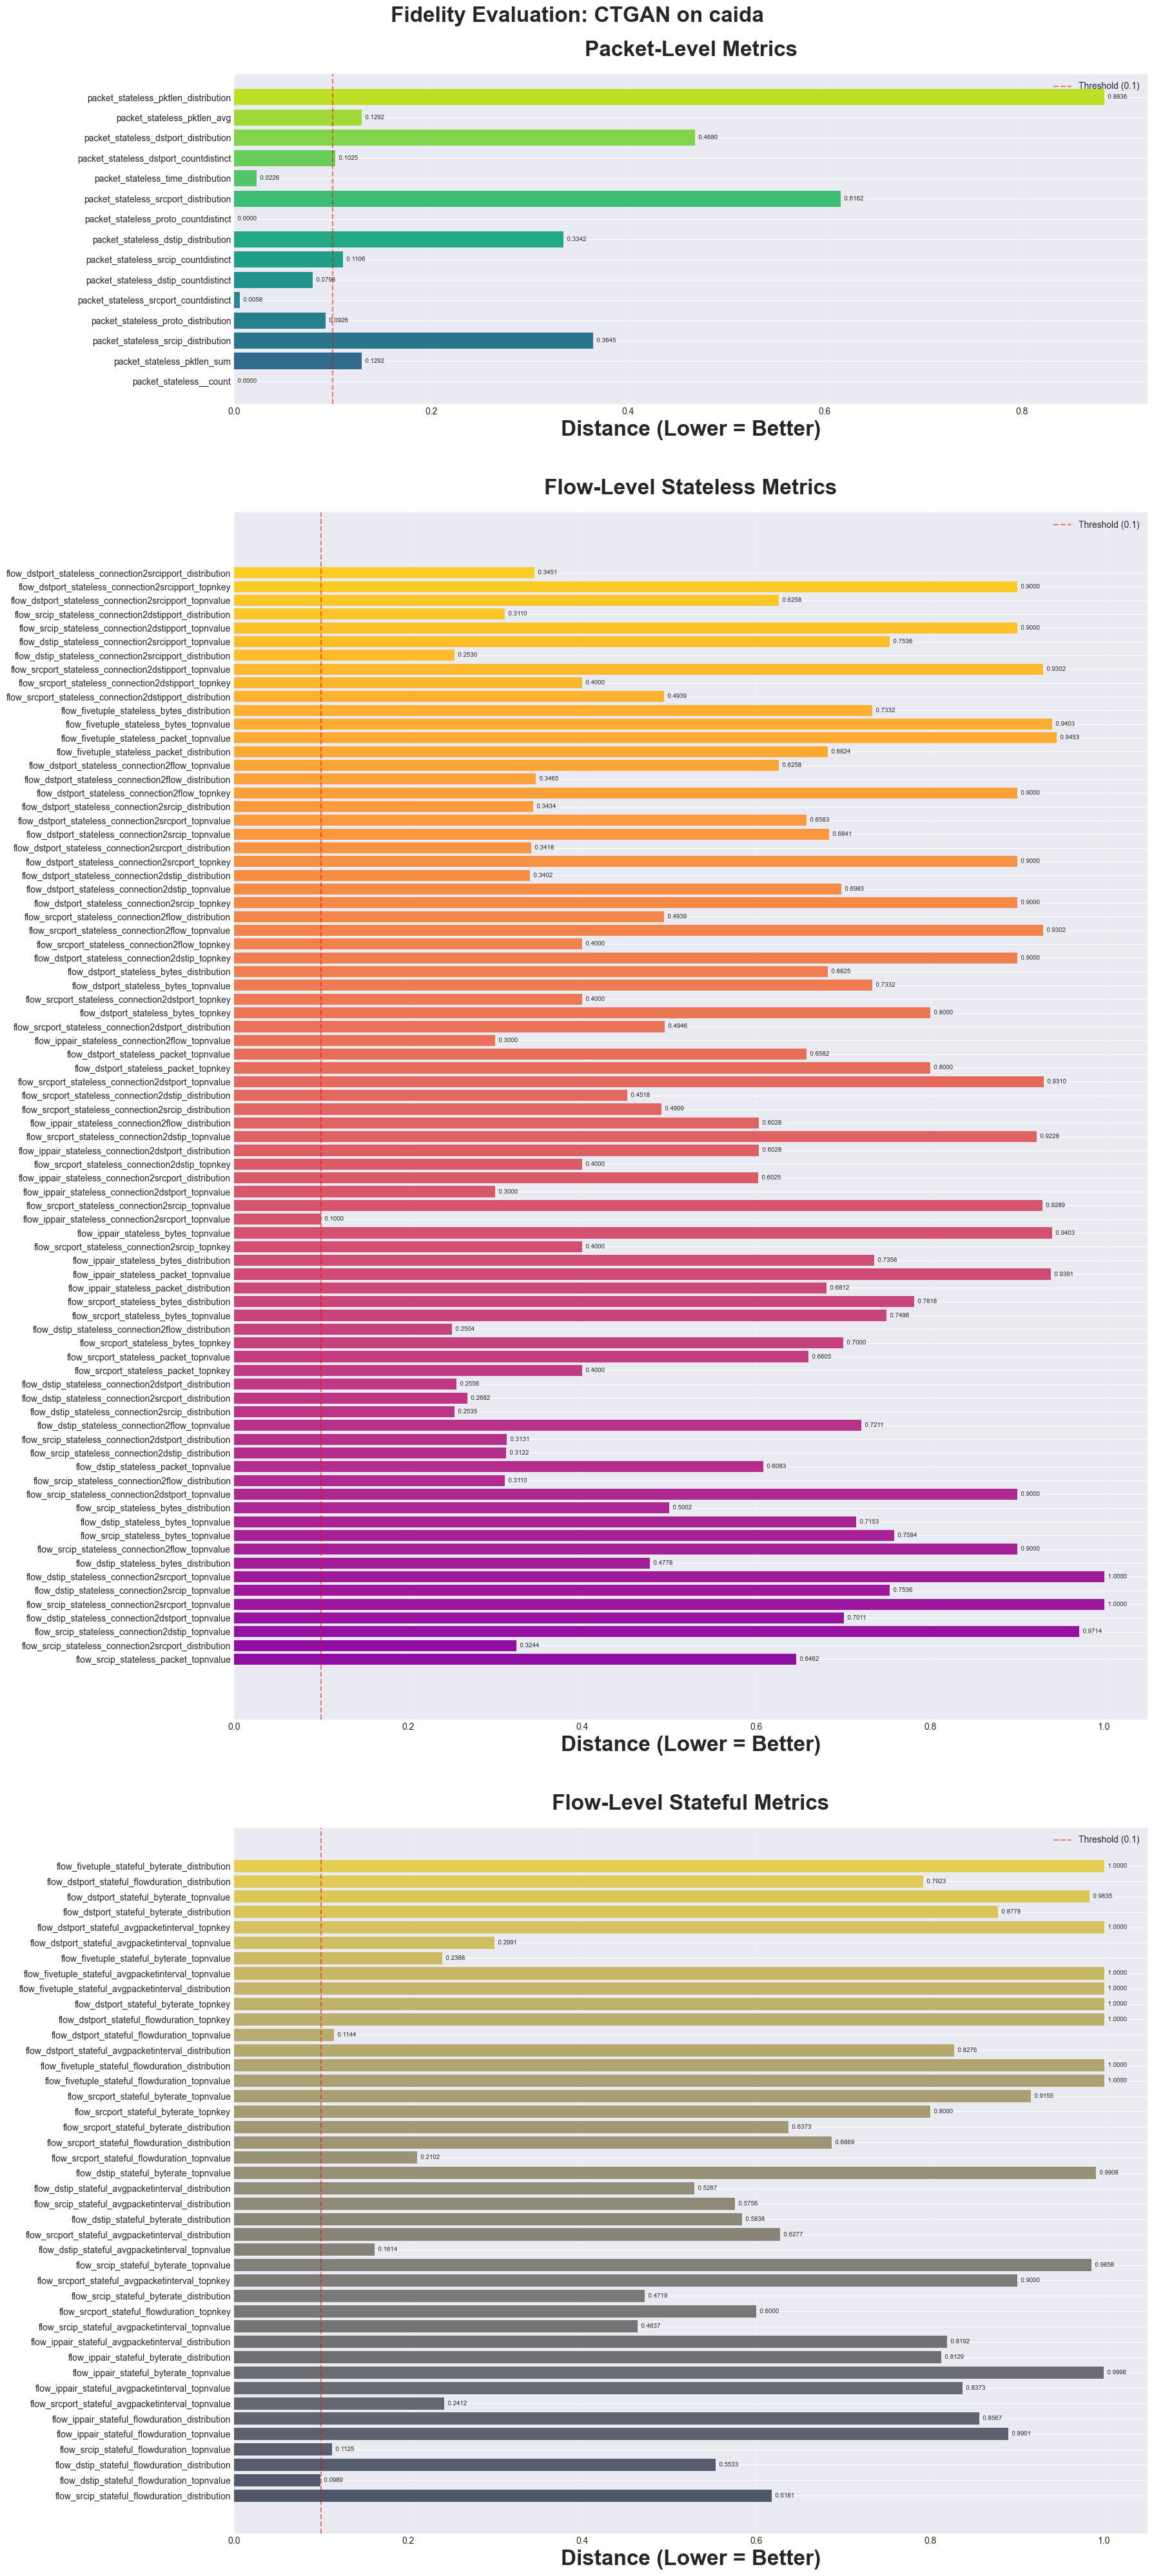


SUMMARY STATISTICS
Total metrics evaluated: 137
Average distance: 0.6004
Median distance: 0.6373
Min distance: 0.0000
Max distance: 1.0000
Metrics below 0.1 threshold: 7/137 (5.1%)


In [10]:
import matplotlib.pyplot as plt
%matplotlib inline

# Display average scores for each category
print("\nAverage Scores by Category:")
print(f"  Packet-Level:            {rst['packet']['avg']:.4f}")
print(f"  Flow-Level Stateless:    {rst['flow_stateless']['avg']:.4f}")
print(f"  Flow-Level Stateful:     {rst['flow_stateful']['avg']:.4f}")
print("\nGenerating visualizations...\n")

# Set up the plotting style
plt.style.use('seaborn-v0_8-darkgrid')
fig = plt.figure(figsize=(18, 40))

# ===== Plot 1: Packet-Level Metrics =====
ax1 = plt.subplot2grid((40, 1), (0, 0), rowspan=6, fig=fig)
packet_metrics = rst['packet']['score']  # Extract the 'score' dictionary
metric_names = list(packet_metrics.keys())
metric_values = list(packet_metrics.values())

# Create color map for better visualization
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(metric_names)))

bars1 = ax1.barh(metric_names, metric_values, color=colors[:len(metric_names)])
ax1.set_xlabel('Distance (Lower = Better)', fontsize=24, fontweight='bold')
ax1.set_title('Packet-Level Metrics', fontsize=24, fontweight='bold', pad=20)
ax1.grid(axis='x', alpha=0.3)

# Add value labels on bars
for i, (name, value) in enumerate(zip(metric_names, metric_values)):
    ax1.text(value, i, f'  {value:.4f}', va='center', fontsize=7)

# Add a reference line at a good threshold (e.g., 0.1)
ax1.axvline(x=0.1, color='red', linestyle='--', alpha=0.5, linewidth=1.5, label='Threshold (0.1)')
ax1.legend(loc='upper right')

# ===== Plot 2: Flow-Level Stateless Metrics =====
ax2 = plt.subplot2grid((40, 1), (7, 0), rowspan=20, fig=fig)
stateless_metrics = rst['flow_stateless']['score']  # Extract the 'score' dictionary
metric_names_sl = list(stateless_metrics.keys())
metric_values_sl = list(stateless_metrics.values())

colors_sl = plt.cm.plasma(np.linspace(0.3, 0.9, len(metric_names_sl)))
bars2 = ax2.barh(metric_names_sl, metric_values_sl, color=colors_sl)
ax2.set_xlabel('Distance (Lower = Better)', fontsize=24, fontweight='bold')
ax2.set_title('Flow-Level Stateless Metrics', fontsize=24, fontweight='bold', pad=20)
ax2.grid(axis='x', alpha=0.3)

# Add value labels on bars
for i, (name, value) in enumerate(zip(metric_names_sl, metric_values_sl)):
    ax2.text(value, i, f'  {value:.4f}', va='center', fontsize=7)

# Add reference line
ax2.axvline(x=0.1, color='red', linestyle='--', alpha=0.5, linewidth=1.5, label='Threshold (0.1)')
ax2.legend(loc='upper right')

# ===== Plot 3: Flow-Level Stateful Metrics =====
ax3 = plt.subplot2grid((40, 1), (28, 0), rowspan=12, fig=fig)
stateful_metrics = rst['flow_stateful']['score']  # Extract the 'score' dictionary
metric_names_sf = list(stateful_metrics.keys())
metric_values_sf = list(stateful_metrics.values())

colors_sf = plt.cm.cividis(np.linspace(0.3, 0.9, len(metric_names_sf)))
bars3 = ax3.barh(metric_names_sf, metric_values_sf, color=colors_sf)
ax3.set_xlabel('Distance (Lower = Better)', fontsize=24, fontweight='bold')
ax3.set_title('Flow-Level Stateful Metrics', fontsize=24, fontweight='bold', pad=20)
ax3.grid(axis='x', alpha=0.3)

# Add value labels on bars
for i, (name, value) in enumerate(zip(metric_names_sf, metric_values_sf)):
    ax3.text(value, i, f'  {value:.4f}', va='center', fontsize=7)

# Add reference line
ax3.axvline(x=0.1, color='red', linestyle='--', alpha=0.5, linewidth=1.5, label='Threshold (0.1)')
ax3.legend(loc='upper right')

# Overall title
fig.suptitle(f'Fidelity Evaluation: {model_name} on {dataset_name}', 
             fontsize=24, fontweight='bold', y=0.998)

plt.tight_layout()
plt.show()

# Calculate and display summary statistics
all_values = metric_values + metric_values_sl + metric_values_sf
print(f"\n{'='*60}")
print(f"SUMMARY STATISTICS")
print(f"{'='*60}")
print(f"Total metrics evaluated: {len(all_values)}")
print(f"Average distance: {np.mean(all_values):.4f}")
print(f"Median distance: {np.median(all_values):.4f}")
print(f"Min distance: {np.min(all_values):.4f}")
print(f"Max distance: {np.max(all_values):.4f}")
below_threshold = sum(v < 0.1 for v in all_values)
print(f"Metrics below 0.1 threshold: {below_threshold}/{len(all_values)} ({100*below_threshold/len(all_values):.1f}%)")
print(f"{'='*60}")
